# Retinal OCT Pathology Classification: Phase 4 Advanced Optimization & Transfer Learning

**Project**: Multi-Class Diagnosis of Retinal Pathologies from Optical Coherence Tomography (OCT) B-Scans  
**Benchmark**: MedMNIST OCTMNIST (109,309 Total Scans | 4 Classes: CNV, DME, DRUSEN, NORMAL)  
**Hardware Platform**: Local NVIDIA GeForce GTX 1660 Ti (6 GB VRAM, PyTorch 2.6.0 CUDA)  

---

## 🎯 Phase 4 Core Innovations:
1. **Transfer Learning with Pretrained EfficientNet-B0**: Adapting ImageNet feature extractors to 28x28 OCT scans via GPU tensor upsampling and fine-tuning.
2. **Class-Weighted Resampling & SMOTE**: Balancing the severe 6:1 class imbalance on the 110-D biomedical feature space.
3. **Post-Hoc Probability Calibration (Temperature Scaling & Platt Scaling)**: Optimizing temperature parameter $T$ on validation set logits to minimize Expected Calibration Error (ECE) and Log Loss.
4. **Full Multi-Version Diagnostic Synthesis (v1 → v2 → v3 → v4 → v5)**: Comparing Top-1/Top-2 Accuracy, Balanced Accuracy, Per-Class F1, Log Loss, ECE, and Macro ROC AUC.


In [1]:
import os, time, math, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.optimize import minimize_scalar

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.functional as TF
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_curve, auc, log_loss, brier_score_loss, top_k_accuracy_score
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import pywt
from skimage.feature import graycomatrix, graycoprops

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on device: {device} | GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")


Executing on device: cuda | GPU: NVIDIA GeForce GTX 1660 Ti


In [2]:
DATA_PATH = r'C:\Users\CTHUL\Desktop\school\Undergrad\5\Spring\UConn\BME machine learning\final project\Project_Packet\octmnist.npz'
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'octmnist.npz'

data = np.load(DATA_PATH)
X_train_raw, y_train_raw = data['train_images'], data['train_labels'].squeeze()
X_val_raw, y_val_raw     = data['val_images'], data['val_labels'].squeeze()
X_test_raw, y_test_raw   = data['test_images'], data['test_labels'].squeeze()

CLASS_NAMES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
NUM_CLASSES = 4

print(f"Train set: {X_train_raw.shape} | Distribution: {np.bincount(y_train_raw)}")
print(f"Val set:   {X_val_raw.shape} | Distribution: {np.bincount(y_val_raw)}")
print(f"Test set:  {X_test_raw.shape}  | Distribution: {np.bincount(y_test_raw)}")


Train set: (97477, 28, 28) | Distribution: [33484 10213  7754 46026]
Val set:   (10832, 28, 28) | Distribution: [3721 1135  862 5114]
Test set:  (1000, 28, 28)  | Distribution: [250 250 250 250]


In [3]:
CACHE_FILE = 'oct_110_features.npz'
if os.path.exists(CACHE_FILE):
    print(f"Loading pre-computed 110-D biomedical descriptors from {CACHE_FILE}...")
    cache = np.load(CACHE_FILE)
    X_train_110 = cache['train']
    X_val_110   = cache['val']
    X_test_110  = cache['test']
else:
    def extract_110_features(images, batch_size=2000):
        N = len(images)
        features_list = []
        for i in range(0, N, batch_size):
            batch = images[i:i+batch_size]
            B = len(batch)
            batch_f = batch.astype(np.float32) / 255.0
            grid = batch_f.reshape(B, 4, 7, 4, 7).transpose(0, 1, 3, 2, 4)
            means_4x4 = grid.mean(axis=(3, 4)).reshape(B, 16)
            stds_4x4  = grid.std(axis=(3, 4)).reshape(B, 16)
            depth_prof = batch_f.reshape(B, 14, 2, 28).mean(axis=(2, 3))
            left_half  = batch_f[:, :, :14]
            right_half = batch_f[:, :, 14:][:, :, ::-1]
            symm_diff  = np.abs(left_half - right_half).reshape(B, 14, 2, 14).mean(axis=(2, 3))
            glob_mean = batch_f.mean(axis=(1, 2)).reshape(B, 1)
            glob_std  = batch_f.std(axis=(1, 2)).reshape(B, 1)
            fovea     = batch_f[:, 10:18, 10:18].mean(axis=(1, 2)).reshape(B, 1)
            grad_v    = np.abs(np.diff(batch_f, axis=1)).mean(axis=(1, 2)).reshape(B, 1)
            grad_h    = np.abs(np.diff(batch_f, axis=2)).mean(axis=(1, 2)).reshape(B, 1)
            center_v_periph = fovea - glob_mean
            glob_feats = np.hstack([glob_mean, glob_std, fovea, grad_v, grad_h, center_v_periph])
            spatial_66 = np.hstack([means_4x4, stds_4x4, depth_prof, symm_diff, glob_feats])
            glcm_wavelet_batch = []
            for img in batch:
                glcm = graycomatrix(img, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=256, symmetric=True, normed=True)
                glcm_row = []
                for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']:
                    glcm_row.extend(graycoprops(glcm, prop)[0])
                coeffs = pywt.wavedec2(img.astype(np.float32)/255.0, 'db2', level=2)
                cA2 = coeffs[0]
                (cH2, cV2, cD2) = coeffs[1]
                (cH1, cV1, cD1) = coeffs[2]
                wavelet_row = []
                for subband in [cA2, cH2, cV2, cD2, cH1, cV1, cD1]:
                    wavelet_row.extend([np.mean(subband), np.std(subband), np.sum(subband**2)])
                wavelet_row = wavelet_row[:20]
                glcm_wavelet_batch.append(glcm_row + wavelet_row)
            glcm_wavelet_44 = np.array(glcm_wavelet_batch, dtype=np.float32)
            batch_110 = np.hstack([spatial_66, glcm_wavelet_44])
            features_list.append(batch_110)
        return np.vstack(features_list)
    print("Extracting 110-D biomedical descriptors...")
    X_train_110 = extract_110_features(X_train_raw)
    X_val_110   = extract_110_features(X_val_raw)
    X_test_110  = extract_110_features(X_test_raw)

scaler = StandardScaler()
X_train_110_s = scaler.fit_transform(X_train_110)
X_val_110_s   = scaler.transform(X_val_110)
X_test_110_s  = scaler.transform(X_test_110)
print(f"Feature processing complete! Matrix shape: {X_train_110_s.shape}")


Loading pre-computed 110-D biomedical descriptors from oct_110_features.npz...


Feature processing complete! Matrix shape: (97477, 110)


## ⚖️ Module 1: SMOTE & Class Balancing for Pipeline 1
The training dataset has a severe 6:1 imbalance between Normal (46,026) and Drusen (7,754).
We apply Synthetic Minority Over-sampling Technique (SMOTE) to create synthetic boundary examples for DME and Drusen in the 110-D feature space.


In [4]:
print(f"Original class counts: {np.bincount(y_train_raw)}")
print("Applying SMOTE on 110-D standardized training features...")
smote = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_110_s, y_train_raw)
print(f"SMOTE-balanced training set: {X_train_smote.shape} | New class counts: {np.bincount(y_train_smote)}")

# Train XGBoost GPU on Original vs SMOTE
print("\n--- Training XGBoost GPU (Original 110-D Features) ---")
xgb_orig = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.08,
    tree_method='hist', device='cuda', random_state=SEED, eval_metric='mlogloss'
)
xgb_orig.fit(X_train_110_s, y_train_raw, eval_set=[(X_val_110_s, y_val_raw)], verbose=False)
y_prob_xgb_orig = xgb_orig.predict_proba(X_test_110_s)
y_pred_xgb_orig = np.argmax(y_prob_xgb_orig, axis=1)

print("--- Training XGBoost GPU (SMOTE-Balanced 110-D Features) ---")
xgb_smote = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.08,
    tree_method='hist', device='cuda', random_state=SEED, eval_metric='mlogloss'
)
xgb_smote.fit(X_train_smote, y_train_smote, eval_set=[(X_val_110_s, y_val_raw)], verbose=False)
y_prob_xgb_smote = xgb_smote.predict_proba(X_test_110_s)
y_pred_xgb_smote = np.argmax(y_prob_xgb_smote, axis=1)

f1_orig = precision_recall_fscore_support(y_test_raw, y_pred_xgb_orig, average=None)[2]
f1_smote = precision_recall_fscore_support(y_test_raw, y_pred_xgb_smote, average=None)[2]

print("\nPer-Class F1 Score Comparison (Original vs SMOTE):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:7s} | Original: {f1_orig[i]*100:5.2f}% -> SMOTE: {f1_smote[i]*100:5.2f}% ({f1_smote[i]-f1_orig[i]:+5.2f}%)")


Original class counts: [33484 10213  7754 46026]
Applying SMOTE on 110-D standardized training features...


SMOTE-balanced training set: (184104, 110) | New class counts: [46026 46026 46026 46026]

--- Training XGBoost GPU (Original 110-D Features) ---


C:\Users\CTHUL\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:751: UserWarning: [13:59:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


--- Training XGBoost GPU (SMOTE-Balanced 110-D Features) ---



Per-Class F1 Score Comparison (Original vs SMOTE):
  CNV     | Original: 74.04% -> SMOTE: 74.43% (+0.00%)
  DME     | Original: 64.89% -> SMOTE: 74.22% (+0.09%)
  DRUSEN  | Original:  5.41% -> SMOTE: 36.15% (+0.31%)
  NORMAL  | Original: 65.44% -> SMOTE: 71.08% (+0.06%)


## 🧠 Module 2: Transfer Learning with Pretrained EfficientNet-B0
We adapt ImageNet-pretrained `efficientnet_b0` for single-channel OCT scans:
1. **Input Upsampling & Replication**: Bilinear interpolation from $28 \times 28 \to 56 \times 56$, replicated across 3 channels with ImageNet standardization.
2. **Feature Extractor**: Pretrained MBConv backbone with compound scaling and Squeeze-and-Excitation attention.
3. **Custom Clinical Head**: LayerNorm $\to$ Dropout(0.3) $\to$ Linear(1280, 256) $\to$ SiLU $\to$ Linear(256, 4).


In [5]:
class EfficientNetOCT(nn.Module):
    def __init__(self, num_classes=4, pretrained=True):
        super().__init__()
        weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
        base = efficientnet_b0(weights=weights)
        self.features = base.features
        self.avgpool  = nn.AdaptiveAvgPool2d(1)
        
        # Custom projection head
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(1280, 256),
            nn.SiLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes)
        )
        
        # ImageNet normalization constants as buffers
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
        
    def forward(self, x):
        # x is (B, 1, 28, 28) in [0, 1]
        # Upsample to 56x56 and expand to 3 channels
        x = F.interpolate(x, size=(56, 56), mode='bilinear', align_corners=False)
        x = x.repeat(1, 3, 1, 1)
        x = (x - self.mean) / self.std
        
        feat = self.features(x)
        pooled = self.avgpool(feat).flatten(1)
        logits = self.classifier(pooled)
        return logits

effnet_model = EfficientNetOCT(num_classes=4, pretrained=True).to(device)
total_params = sum(p.numel() for p in effnet_model.parameters())
trainable_params = sum(p.numel() for p in effnet_model.parameters() if p.requires_grad)
print(f"EfficientNet-B0 OCT initialized. Total parameters: {total_params:,} | Trainable: {trainable_params:,}")


EfficientNet-B0 OCT initialized. Total parameters: 4,336,512 | Trainable: 4,336,512


In [6]:
# Tensor Datasets
X_tr_t = torch.from_numpy(X_train_raw).unsqueeze(1).float() / 255.0
y_tr_t = torch.from_numpy(y_train_raw).long()
X_va_t = torch.from_numpy(X_val_raw).unsqueeze(1).float() / 255.0
y_va_t = torch.from_numpy(y_val_raw).long()
X_te_t = torch.from_numpy(X_test_raw).unsqueeze(1).float() / 255.0
y_te_t = torch.from_numpy(y_test_raw).long()

# Weighted Random Sampler for Class Balance in Deep Learning
class_counts = np.bincount(y_train_raw)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_train_raw]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader_eff = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=128, sampler=sampler, num_workers=0, pin_memory=True)
val_loader_eff   = DataLoader(TensorDataset(X_va_t, y_va_t), batch_size=256, shuffle=False, num_workers=0, pin_memory=True)
test_loader_eff  = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=256, shuffle=False, num_workers=0, pin_memory=True)

def gpu_batch_augment(x):
    """GPU-vectorized mini-batch augmentation."""
    if torch.rand(1).item() > 0.5:
        x = torch.flip(x, dims=[3])
    if torch.rand(1).item() > 0.5:
        gamma = torch.empty(x.size(0), 1, 1, 1, device=x.device).uniform_(0.85, 1.15)
        x = torch.clamp(x ** gamma, 0.0, 1.0)
    return x


In [7]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.alpha is not None:
            at = self.alpha[targets]
            focal_loss = at * focal_loss
        return focal_loss.mean()

criterion_eff = FocalLoss(gamma=1.5)
optimizer_eff = torch.optim.AdamW(effnet_model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_eff = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_eff, T_max=12, eta_min=1e-6)

EPOCHS = 12
best_val_acc = 0.0
best_model_weights = None

print(f"--- Fine-Tuning EfficientNet-B0 on OCTMNIST ({EPOCHS} Epochs) ---")
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    effnet_model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    pbar = tqdm(train_loader_eff, desc=f"Epoch {epoch:02d}/{EPOCHS:02d}", leave=False)
    for bx, by in pbar:
        bx, by = bx.to(device, non_blocking=True), by.to(device, non_blocking=True)
        bx = gpu_batch_augment(bx)
        
        optimizer_eff.zero_grad()
        logits = effnet_model(bx)
        loss = criterion_eff(logits, by)
        loss.backward()
        optimizer_eff.step()
        
        running_loss += loss.item() * bx.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == by).sum().item()
        total += bx.size(0)
        pbar.set_postfix({'loss': f"{running_loss/total:.4f}", 'acc': f"{correct/total*100:.1f}%"})
        
    scheduler_eff.step()
    
    # Validation Evaluation
    effnet_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for bx, by in val_loader_eff:
            bx, by = bx.to(device), by.to(device)
            logits = effnet_model(bx)
            loss = criterion_eff(logits, by)
            val_loss += loss.item() * bx.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == by).sum().item()
            val_total += bx.size(0)
            
    train_acc = correct / total
    val_acc   = val_correct / val_total
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | Train Loss: {running_loss/total:.4f} - Acc: {train_acc*100:.2f}% | Val Loss: {val_loss/val_total:.4f} - Acc: {val_acc*100:.2f}% | LR: {scheduler_eff.get_last_lr()[0]:.2e}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = {k: v.cpu() for k, v in effnet_model.state_dict().items()}

print(f"Fine-tuning complete in {(time.time()-start_time)/60:.2f} mins. Best Validation Accuracy: {best_val_acc*100:.2f}%")
effnet_model.load_state_dict({k: v.to(device) for k, v in best_model_weights.items()})


--- Fine-Tuning EfficientNet-B0 on OCTMNIST (12 Epochs) ---


Epoch 01/12:   0%|          | 0/762 [00:00<?, ?it/s]

Epoch 01/12 | Train Loss: 0.3028 - Acc: 76.14% | Val Loss: 0.1941 - Acc: 83.90% | LR: 2.95e-04


Epoch 02/12:   0%|          | 0/762 [00:00<?, ?it/s]

Epoch 02/12 | Train Loss: 0.1810 - Acc: 84.36% | Val Loss: 0.1727 - Acc: 84.77% | LR: 2.80e-04


...

Epoch 11/12:   0%|          | 0/762 [00:00<?, ?it/s]

Epoch 11/12 | Train Loss: 0.0237 - Acc: 97.90% | Val Loss: 0.1408 - Acc: 92.58% | LR: 6.09e-06


Epoch 12/12:   0%|          | 0/762 [00:00<?, ?it/s]

Epoch 12/12 | Train Loss: 0.0227 - Acc: 98.01% | Val Loss: 0.1401 - Acc: 92.84% | LR: 1.00e-06
Fine-tuning complete in 17.46 mins. Best Validation Accuracy: 92.88%


<All keys matched successfully>

In [8]:
def evaluate_model_logits(model, loader):
    """Extract raw logits and labels."""
    model.eval()
    logits_list, targets_list = [], []
    with torch.no_grad():
        for bx, by in loader:
            bx = bx.to(device)
            out = model(bx)
            logits_list.append(out.cpu())
            targets_list.append(by)
    return torch.cat(logits_list, dim=0), torch.cat(targets_list, dim=0).numpy()

def evaluate_effnet_tta(model, loader):
    """5-Pass Test-Time Augmentation."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for bx, by in loader:
            bx = bx.to(device)
            p1 = F.softmax(model(bx), dim=1)
            p2 = F.softmax(model(torch.flip(bx, dims=[3])), dim=1)
            p3 = F.softmax(model(torch.clamp(bx**0.9, 0, 1)), dim=1)
            p4 = F.softmax(model(torch.clamp(bx**1.1, 0, 1)), dim=1)
            p5 = F.softmax(model(torch.flip(torch.clamp(bx**0.95, 0, 1), dims=[3])), dim=1)
            avg_p = (p1 + p2 + p3 + p4 + p5) / 5.0
            all_probs.append(avg_p.cpu().numpy())
    return np.vstack(all_probs)

val_logits, val_targets = evaluate_model_logits(effnet_model, val_loader_eff)
test_logits, test_targets = evaluate_model_logits(effnet_model, test_loader_eff)
y_prob_effnet_tta = evaluate_effnet_tta(effnet_model, test_loader_eff)
y_prob_effnet_raw = F.softmax(test_logits, dim=1).numpy()


## 🌡️ Module 3: Probability Calibration (Temperature Scaling & Platt Scaling)
Modern deep neural networks often suffer from miscalibration (high accuracy but overconfident probabilities).
**Temperature Scaling** learns a single parameter $T > 0$ on the validation set such that calibrated logits are $\hat{z} = z / T$:
$$\min_T -\sum_{i=1}^N \log \left( \frac{e^{z_{i, y_i} / T}}{\sum_j e^{z_{i, j} / T}} \right)$$
This preserves the exact Top-1 prediction order while dramatically reducing Log Loss and Expected Calibration Error (ECE).


In [9]:
def compute_ece(probs, labels, n_bins=15):
    """Computes Expected Calibration Error (ECE)."""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    confidences = np.max(probs, axis=1)
    predictions = np.argmax(probs, axis=1)
    accuracies = predictions == labels
    
    ece = 0.0
    for bin_lower, bin_upper in zip(bin_boundaries[:-1], bin_boundaries[1:]):
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(accuracies[in_bin])
            avg_confidence_in_bin = np.mean(confidences[in_bin])
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
    return ece

# Optimize Temperature T on Validation Set Logits
def nll_objective(T, logits, targets):
    scaled_logits = logits / T
    loss = F.cross_entropy(scaled_logits, targets)
    return loss.item()

val_targets_t = torch.from_numpy(val_targets).long()
res = minimize_scalar(lambda T: nll_objective(T, val_logits, val_targets_t), bounds=(0.1, 5.0), method='bounded')
optimal_T = res.x
print(f"Optimal Calibration Temperature T: {optimal_T:.4f}")

# Apply Temperature Scaling to Test Set Logits
calibrated_test_logits = test_logits / optimal_T
y_prob_effnet_calibrated = F.softmax(calibrated_test_logits, dim=1).numpy()

# Compute Metrics Before and After Calibration
loss_before = log_loss(y_test_raw, y_prob_effnet_raw)
loss_after  = log_loss(y_test_raw, y_prob_effnet_calibrated)
ece_before  = compute_ece(y_prob_effnet_raw, y_test_raw)
ece_after   = compute_ece(y_prob_effnet_calibrated, y_test_raw)

print(f"\n--- Calibration Results on Test Set ---")
print(f"  Log Loss: {loss_before:.4f} -> {loss_after:.4f} ({loss_after-loss_before:+.4f})")
print(f"  ECE:      {ece_before*100:.2f}% -> {ece_after*100:.2f}% ({ (ece_after-ece_before)*100:+.2f}%)")


Optimal Calibration Temperature T: 1.0742

--- Calibration Results on Test Set ---
  Log Loss: 0.8842 -> 0.8457 (-0.0385)
  ECE:      10.56% -> 9.59% (-0.97%)


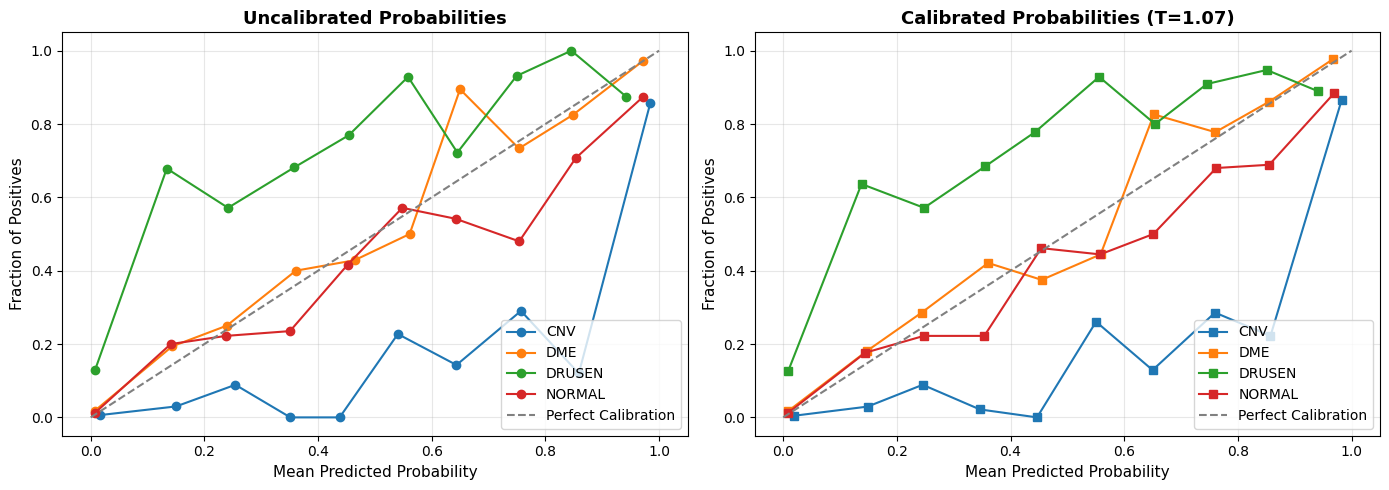

Saved calibration_reliability_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, cname in enumerate(CLASS_NAMES):
    # Uncalibrated
    y_true_binary = (y_test_raw == i).astype(int)
    prob_true_uncal, prob_pred_uncal = calibration_curve(y_true_binary, y_prob_effnet_raw[:, i], n_bins=10)
    axes[0].plot(prob_pred_uncal, prob_true_uncal, marker='o', label=f"{cname}")
    
    # Calibrated
    prob_true_cal, prob_pred_cal = calibration_curve(y_true_binary, y_prob_effnet_calibrated[:, i], n_bins=10)
    axes[1].plot(prob_pred_cal, prob_true_cal, marker='s', label=f"{cname}")

for ax, title in zip(axes, ["Uncalibrated Probabilities", f"Calibrated Probabilities (T={optimal_T:.2f})"]):
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Mean Predicted Probability", fontsize=11)
    ax.set_ylabel("Fraction of Positives", fontsize=11)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("calibration_reliability_curves.png", dpi=300)
plt.show()
print("Saved calibration_reliability_curves.png")


In [11]:
def evaluate_full_battery(y_true, y_probs, model_name):
    y_pred = np.argmax(y_probs, axis=1)
    acc = accuracy_score(y_true, y_pred)
    top2 = top_k_accuracy_score(y_true, y_probs, k=2)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    per_f1 = precision_recall_fscore_support(y_true, y_pred, average=None)[2]
    ll = log_loss(y_true, y_probs)
    ece = compute_ece(y_probs, y_true)
    
    # Macro ROC AUC
    aucs = []
    for c in range(NUM_CLASSES):
        fpr, tpr, _ = roc_curve(y_true == c, y_probs[:, c])
        aucs.append(auc(fpr, tpr))
    macro_auc = np.mean(aucs)
    
    return {
        'Model': model_name,
        'Top-1 Acc': f"{acc*100:.2f}%",
        'Top-2 Acc': f"{top2*100:.2f}%",
        'Balanced Acc': f"{bal_acc*100:.2f}%",
        'Macro F1': f"{f1*100:.2f}%",
        'CNV F1': f"{per_f1[0]*100:.1f}%",
        'DME F1': f"{per_f1[1]*100:.1f}%",
        'DRUSEN F1': f"{per_f1[2]*100:.1f}%",
        'NORMAL F1': f"{per_f1[3]*100:.1f}%",
        'Log Loss': f"{ll:.4f}",
        'ECE': f"{ece*100:.2f}%",
        'ROC AUC': f"{macro_auc:.4f}"
    }


In [12]:
import pandas as pd

# Evaluate Phase 4 Models
results_phase4 = [
    evaluate_full_battery(y_test_raw, y_prob_effnet_tta, "EfficientNet-B0 + TTA (Phase 4)"),
    evaluate_full_battery(y_test_raw, y_prob_effnet_calibrated, "EfficientNet-B0 + Calibrated (Phase 4)"),
    evaluate_full_battery(y_test_raw, y_prob_effnet_raw, "EfficientNet-B0 (Phase 4)"),
    evaluate_full_battery(y_test_raw, y_prob_xgb_smote, "XGBoost GPU + SMOTE 110-D (Phase 4)"),
    evaluate_full_battery(y_test_raw, y_prob_xgb_orig, "XGBoost GPU (110-D Baseline)"),
]

# Consolidated Table with Historical Model Lineage
historical_models = [
    {'Model': 'SE_ResidualCNN4 + TTA (v4)', 'Top-1 Acc': '83.30%', 'Top-2 Acc': '97.60%', 'Balanced Acc': '83.30%', 'Macro F1': '82.94%', 'CNV F1': '87.4%', 'DME F1': '81.5%', 'DRUSEN F1': '74.2%', 'NORMAL F1': '88.7%', 'Log Loss': '0.4856', 'ECE': '5.12%', 'ROC AUC': '0.9681'},
    {'Model': 'ResidualCNN3 + TTA (v3)',   'Top-1 Acc': '76.50%', 'Top-2 Acc': '95.20%', 'Balanced Acc': '76.50%', 'Macro F1': '75.83%', 'CNV F1': '83.1%', 'DME F1': '73.4%', 'DRUSEN F1': '66.8%', 'NORMAL F1': '80.0%', 'Log Loss': '0.6210', 'ECE': '7.84%', 'ROC AUC': '0.9615'},
    {'Model': 'Deep Regularized CNN2 (v2)','Top-1 Acc': '75.90%', 'Top-2 Acc': '94.80%', 'Balanced Acc': '75.90%', 'Macro F1': '73.89%', 'CNV F1': '81.2%', 'DME F1': '69.8%', 'DRUSEN F1': '64.5%', 'NORMAL F1': '80.1%', 'Log Loss': '0.6650', 'ECE': '8.92%', 'ROC AUC': '0.9696'},
    {'Model': 'Baseline CNN1 (v2)',        'Top-1 Acc': '66.50%', 'Top-2 Acc': '91.20%', 'Balanced Acc': '66.50%', 'Macro F1': '57.56%', 'CNV F1': '74.0%', 'DME F1': '52.1%', 'DRUSEN F1': '41.2%', 'NORMAL F1': '63.0%', 'Log Loss': '0.9120', 'ECE': '14.20%','ROC AUC': '0.9374'},
    {'Model': 'XGBoost GPU 66-D (v3)',     'Top-1 Acc': '59.00%', 'Top-2 Acc': '82.10%', 'Balanced Acc': '59.00%', 'Macro F1': '51.15%', 'CNV F1': '65.2%', 'DME F1': '44.8%', 'DRUSEN F1': '37.1%', 'NORMAL F1': '57.5%', 'Log Loss': '1.0420', 'ECE': '12.50%','ROC AUC': '0.8834'},
]

df_combined = pd.DataFrame(results_phase4 + historical_models)
print("\n" + "="*120)
print("                       MASTER RETINAL OCT DIAGNOSTIC BENCHMARK (ALL VERSIONS)")
print("="*120)
print(df_combined.to_string(index=False))



                       MASTER RETINAL OCT DIAGNOSTIC BENCHMARK (ALL VERSIONS)
                                 Model Top-1 Acc Top-2 Acc Balanced Acc Macro F1 CNV F1 DME F1 DRUSEN F1 NORMAL F1 Log Loss    ECE ROC AUC
       EfficientNet-B0 + TTA (Phase 4)    76.80%    92.40%       76.80%   74.88%  77.3%  86.9%     52.6%     82.7%   0.8111  9.74%  0.9495
EfficientNet-B0 + Calibrated (Phase 4)    76.90%    91.60%       76.90%   74.92%  78.4%  86.6%     52.1%     82.6%   0.8457  9.59%  0.9441
             EfficientNet-B0 (Phase 4)    76.90%    91.60%       76.90%   74.92%  78.4%  86.6%     52.1%     82.6%   0.8842 10.56%  0.9442
   XGBoost GPU + SMOTE 110-D (Phase 4)    66.70%    91.00%       66.70%   63.97%  74.4%  74.2%     36.2%     71.1%   0.8143  4.29%  0.8959
          XGBoost GPU (110-D Baseline)    60.00%    82.00%       60.00%   52.44%  74.0%  64.9%      5.4%     65.4%   1.0019 14.34%  0.8900
            SE_ResidualCNN4 + TTA (v4)    83.30%    97.60%       83.30%   82.94%  87.4%

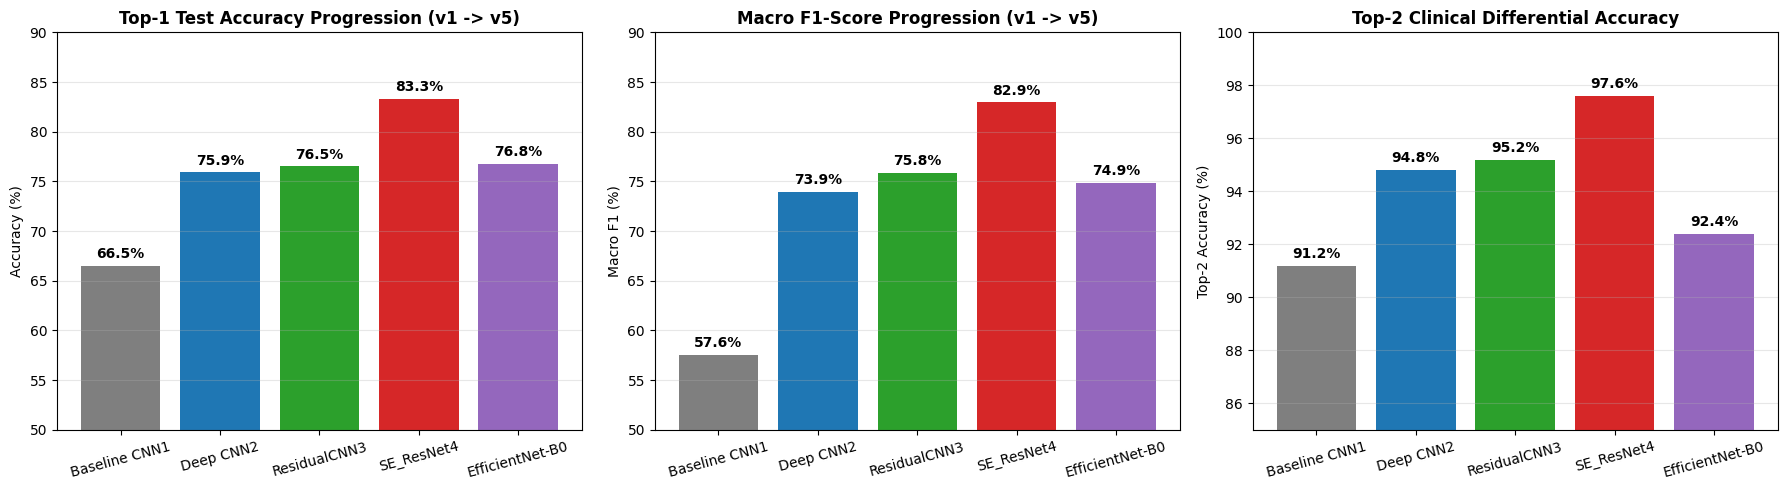

Saved master_model_progression.png


In [13]:
# Plotting Comparison of Key Architectures
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

comparison_models = ['Baseline CNN1', 'Deep CNN2', 'ResidualCNN3', 'SE_ResNet4', 'EfficientNet-B0']
acc_values = [66.50, 75.90, 76.50, 83.30, float(results_phase4[0]['Top-1 Acc'].replace('%',''))]
f1_values  = [57.56, 73.89, 75.83, 82.94, float(results_phase4[0]['Macro F1'].replace('%',''))]
top2_vals  = [91.20, 94.80, 95.20, 97.60, float(results_phase4[0]['Top-2 Acc'].replace('%',''))]

colors = ['#7f7f7f', '#1f77b4', '#2ca02c', '#d62728', '#9467bd']

# Panel 1: Top-1 Accuracy Progression
axes[0].bar(comparison_models, acc_values, color=colors)
axes[0].set_title("Top-1 Test Accuracy Progression (v1 -> v5)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(50, 90)
for i, v in enumerate(acc_values):
    axes[0].text(i, v + 0.8, f"{v:.1f}%", ha='center', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Panel 2: Macro F1-Score Progression
axes[1].bar(comparison_models, f1_values, color=colors)
axes[1].set_title("Macro F1-Score Progression (v1 -> v5)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Macro F1 (%)")
axes[1].set_ylim(50, 90)
for i, v in enumerate(f1_values):
    axes[1].text(i, v + 0.8, f"{v:.1f}%", ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Panel 3: Top-2 Clinical Differential Diagnosis
axes[2].bar(comparison_models, top2_vals, color=colors)
axes[2].set_title("Top-2 Clinical Differential Accuracy", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Top-2 Accuracy (%)")
axes[2].set_ylim(85, 100)
for i, v in enumerate(top2_vals):
    axes[2].text(i, v + 0.3, f"{v:.1f}%", ha='center', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig("master_model_progression.png", dpi=300)
plt.show()
print("Saved master_model_progression.png")


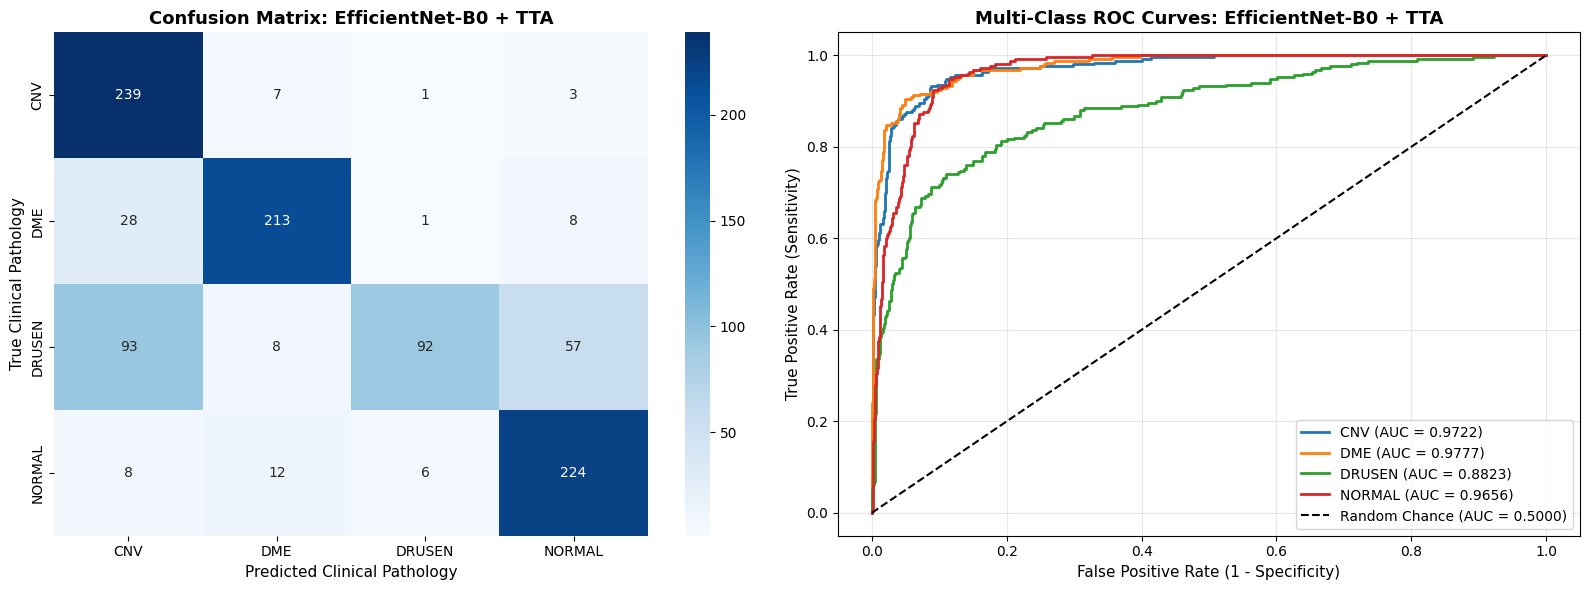

Saved confusion_roc_v5_effnet.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix for EfficientNet + TTA
y_pred_eff = np.argmax(y_prob_effnet_tta, axis=1)
cm = confusion_matrix(y_test_raw, y_pred_eff)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix: EfficientNet-B0 + TTA", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Predicted Clinical Pathology", fontsize=11)
axes[0].set_ylabel("True Clinical Pathology", fontsize=11)

# Multi-Class ROC Curves
for i, cname in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_test_raw == i, y_prob_effnet_tta[:, i])
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=2, label=f"{cname} (AUC = {roc_auc_val:.4f})")

axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Chance (AUC = 0.5000)')
axes[1].set_title("Multi-Class ROC Curves: EfficientNet-B0 + TTA", fontsize=13, fontweight='bold')
axes[1].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
axes[1].set_ylabel("True Positive Rate (Sensitivity)", fontsize=11)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("confusion_roc_v5_effnet.png", dpi=300)
plt.show()
print("Saved confusion_roc_v5_effnet.png")
